In [1]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
from full_model import pre_process_data
from scipy.signal import find_peaks
from scipy.signal import peak_widths



con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, value, pid,delimit_value, delimit_value2,analysis, protein_value, label, interpretation, age, total_igg, total_iga,total_igm, gender
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()

df = pre_process_data(df['id'],df)
con.close()

valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]

df = train_rows

Exception: This row did not contain all neccessary information!

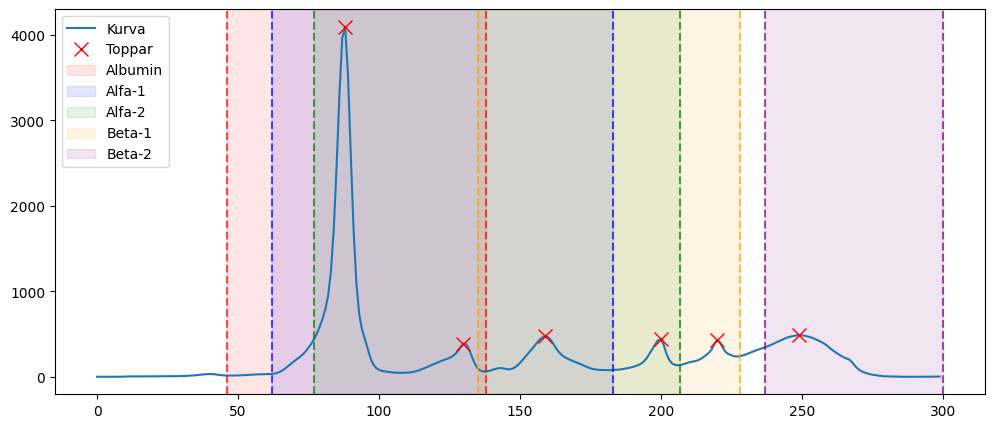

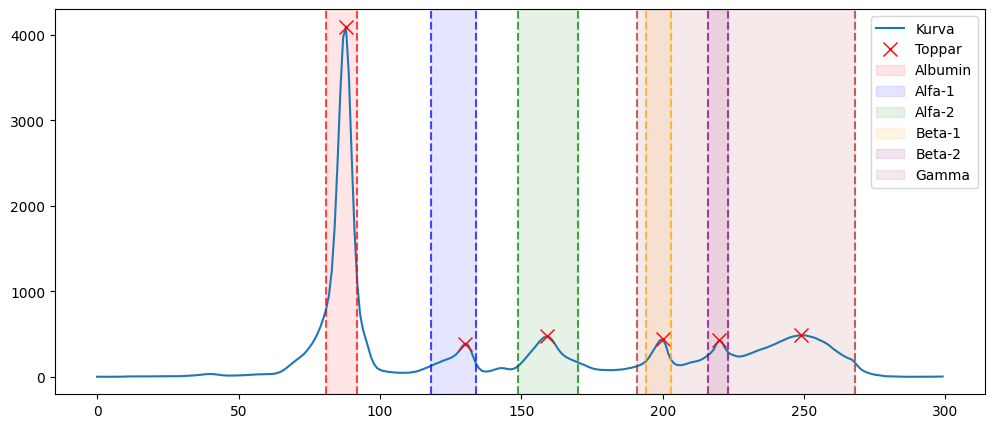

Capillary gränser:
  Albumin: 46 - 138
  Alfa-1: 62 - 183
  Alfa-2: 77 - 207
  Beta-1: 135 - 228
  Beta-2: 237 - 300
['1' '01' '0109' '0109' '46138' '0138' '62183' '0183' '77207' '0207'
 '135228' '0228' '237300' '0300' '3']

Mina gränser (peak_widths):
  Albumin: 81 - 92
  Alfa-1: 118 - 134
  Alfa-2: 149 - 170
  Beta-1: 194 - 203
  Beta-2: 216 - 223
  Gamma: 191 - 268


In [ ]:
row = df.iloc[2,:]
values = row['value']
peaks, properties = find_peaks(values,prominence=6,distance=10)
top6_idx = np.argsort(properties['prominences'])[-6:]
peaks = np.sort(peaks[top6_idx])  # sortera i positions-ordning
widths, heights, left_ips, right_ips = peak_widths(values, peaks, rel_height=0.8)
left_ips = left_ips.astype(int)
right_ips = right_ips.astype(int)
FRACTION_LABELS = ['Albumin', 'Alfa-1', 'Alfa-2', 'Beta-1', 'Beta-2', 'Gamma']

def parse_delimit2(delimit2):
    values = delimit2[2:-1]  # skippa 1, 01 och sista flaggan
    
    # skippa även första paret (0106, 0106) = prealbumin
    values = values[2:]
    
    boundaries = []
    for i in range(0, len(values), 2):
        val = str(values[i])
        end = int(val[-3:])
        start = int(val[:-3])
        boundaries.append((start, end))
    
    return boundaries

plt.figure(figsize=(12, 5))

plt.plot(values, label='Kurva')
plt.plot(peaks, values[peaks], 'x', markersize=10, color='red', label='Toppar')

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
boundaries = parse_delimit2(row['delimit_value2'])
for i, ((start, end), label, color) in enumerate(zip(boundaries, FRACTION_LABELS, colors)):
    plt.axvline(x=start, color=color, linestyle='--', alpha=0.7)
    plt.axvline(x=end, color=color, linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.1, color=color, label=label)

plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(values, label='Kurva')
plt.plot(peaks, values[peaks], 'x', markersize=10, color='red', label='Toppar')

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i, (start, end, label, color) in enumerate(zip(left_ips,right_ips, FRACTION_LABELS, colors)):
    plt.axvline(x=start, color=color, linestyle='--', alpha=0.7)
    plt.axvline(x=end, color=color, linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.1, color=color, label=label)

plt.legend()
plt.show()

print("Capillary gränser:")
for label, (start, end) in zip(FRACTION_LABELS, boundaries):
    print(f"  {label}: {start} - {end}")

print(row['delimit_value2'])

print("\nMina gränser (peak_widths):")
for label, start, end in zip(FRACTION_LABELS, left_ips, right_ips):
    print(f"  {label}: {start} - {end}")


In [68]:
def calculate_fractions(values, peaks):
    values = np.array(values, dtype=float)
    total_area = np.trapezoid(values)
    
    boundaries = [0]
    for i in range(len(peaks) - 1):
        # hitta minimum mellan topparna = naturlig dalgång
        valley = np.argmin(values[peaks[i]:peaks[i+1]]) + peaks[i]
        boundaries.append(valley)
    boundaries.append(len(values))
    
    fractions = []
    for i in range(len(peaks)):
        area = np.trapezoid(values[boundaries[i]:boundaries[i+1]])
        fractions.append(100 * area / total_area)
    
    return fractions
print("Mina beräkningar:")
fractions = calculate_fractions(row['value'], peaks)
for label, frac in zip(FRACTION_LABELS, fractions):
    print(f"{label}: {frac:.1f}%")
print("\n\nCapillary:")
for label, frac in zip(FRACTION_LABELS, row['delimit_value']):
    print(f"{label}: {frac:.1f}%")


Mina beräkningar:
Albumin: 48.2%
Alfa-1: 6.4%
Alfa-2: 11.4%
Beta-1: 6.1%
Beta-2: 6.7%
Gamma: 20.5%


Capillary:
Albumin: 48.4%
Alfa-1: 6.5%
Alfa-2: 11.6%
Beta-1: 6.2%
Beta-2: 7.0%
Gamma: 20.3%
